# Datawell Consultancy
## Project: Financial Transaction Analytics
### Phase 2 — KPI Analysis & Business Insights
---
**Prepared by:** Datawell Consultancy

**Prerequisite:** Run `01_data_quality.ipynb` first to generate cleaned data in `data/cleaned/`

In [19]:
import os
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set base directory to repo root
BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
RAW_DATA_DIR = os.path.join(BASE_DIR,'data','raw')
CLEANED_DATA_DIR = os.path.join(BASE_DIR,'data','cleaned')
NOTEBOOKS_DIR = os.path.join(BASE_DIR,'notebooks')
DASHBOARD_DIR = os.path.join(BASE_DIR,'dashboard')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

master = pd.read_csv(os.path.join(CLEANED_DATA_DIR,'master_dataset.csv'))
master['txn_datetime'] = pd.to_datetime(master['txn_datetime'])
master['txn_date'] = pd.to_datetime(master['txn_date'])

print(f'All good! Master dataset loaded: {len(master):,} transactions')
print(f'Date range: {master["txn_date"].min()} to {master["txn_date"].max()}')

All good! Master dataset loaded: 1,330,829 transactions
Date range: 2010-01-01 00:00:00 to 2019-10-31 00:00:00


## KPI 1: Executive Summary

In [20]:
kpi_overview = duckdb.query("""
    SELECT
        COUNT(*)                                                           AS total_transactions,
        COUNT(DISTINCT user_id)                                            AS unique_customers,
        COUNT(DISTINCT merchant_id)                                        AS unique_merchants,
        ROUND(SUM(amount_abs), 2)                                          AS total_volume_usd,
        ROUND(AVG(amount_abs), 2)                                          AS avg_txn_value_usd,
        ROUND(MEDIAN(amount_abs), 2)                                       AS median_txn_value_usd,
        SUM(CASE WHEN has_error = 'True' THEN 1 ELSE 0 END)               AS error_transactions,
        ROUND(AVG(CASE WHEN has_error = 'True' THEN 1.0 ELSE 0 END)*100, 2) AS error_rate_pct,
        SUM(CASE WHEN is_reversal = 'True' THEN 1 ELSE 0 END)             AS total_reversals,
        SUM(CASE WHEN is_online = 'True' THEN 1 ELSE 0 END)               AS online_transactions
    FROM master
""").df()

print('\n' + '='*55)
print('  EXECUTIVE KPI SUMMARY')
print('='*55)
for col in kpi_overview.columns:
    val = kpi_overview[col].iloc[0]
    if isinstance(val, float):
        print(f'  {col:<35}: {val:>15,.2f}')
    else:
        print(f'  {col:<35}: {val:>15,}')
print('='*55)


  EXECUTIVE KPI SUMMARY
  total_transactions                 :       1,330,829
  unique_customers                   :           1,219
  unique_merchants                   :          33,886
  total_volume_usd                   :   70,575,952.28
  avg_txn_value_usd                  :           53.03
  median_txn_value_usd               :           34.79
  error_transactions                 :       21,019.00
  error_rate_pct                     :            1.58
  total_reversals                    :       65,796.00
  online_transactions                :      156,630.00


## KPI 2: Yearly Transaction Trends

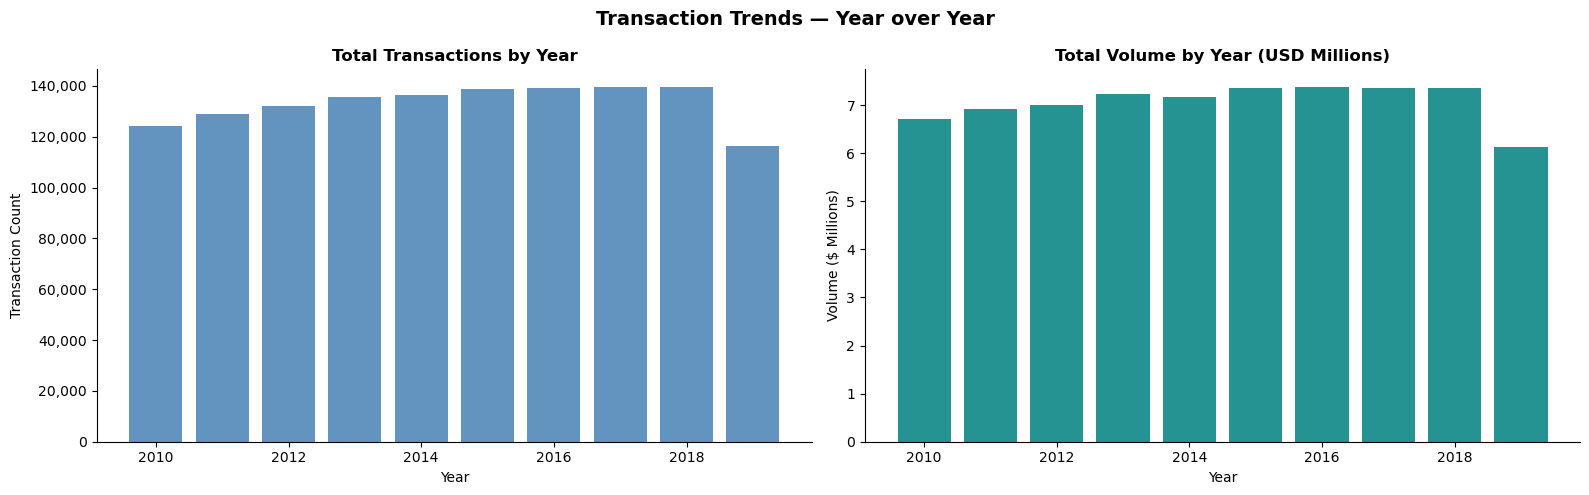

 txn_year  total_txns  total_volume  avg_txn_value  error_rate_pct
     2010      124098  6,706,009.00          54.04            1.51
     2011      129058  6,928,059.00          53.68            1.60
     2012      132029  6,996,364.00          52.99            1.55
     2013      135686  7,231,864.00          53.30            1.60
     2014      136531  7,169,393.00          52.51            1.54
     2015      138636  7,349,534.00          53.01            1.57
     2016      139300  7,374,442.00          52.94            1.63
     2017      139485  7,353,502.00          52.72            1.58
     2018      139575  7,348,520.00          52.65            1.59
     2019      116431  6,118,266.00          52.55            1.61


In [21]:
yearly = duckdb.query("""
    SELECT
        txn_year,
        COUNT(*)                                                           AS total_txns,
        ROUND(SUM(amount_abs), 0)                                          AS total_volume,
        ROUND(AVG(amount_abs), 2)                                          AS avg_txn_value,
        ROUND(AVG(CASE WHEN has_error = 'True' THEN 1.0 ELSE 0 END)*100, 2) AS error_rate_pct
    FROM master
    GROUP BY txn_year
    ORDER BY txn_year
""").df()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.bar(yearly['txn_year'], yearly['total_txns'], color='steelblue', alpha=0.85)
ax1.set_title('Total Transactions by Year', fontweight='bold', fontsize=12)
ax1.set_xlabel('Year')
ax1.set_ylabel('Transaction Count')
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))

ax2.bar(yearly['txn_year'], yearly['total_volume']/1e6, color='teal', alpha=0.85)
ax2.set_title('Total Volume by Year (USD Millions)', fontweight='bold', fontsize=12)
ax2.set_xlabel('Year')
ax2.set_ylabel('Volume ($ Millions)')

plt.suptitle('Transaction Trends — Year over Year', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DASHBOARD_DIR,'yearly_trends.png'), dpi=150, bbox_inches='tight')
plt.show()

print(yearly.to_string(index=False))

## KPI 3: Channel Analysis — Online vs In-Store

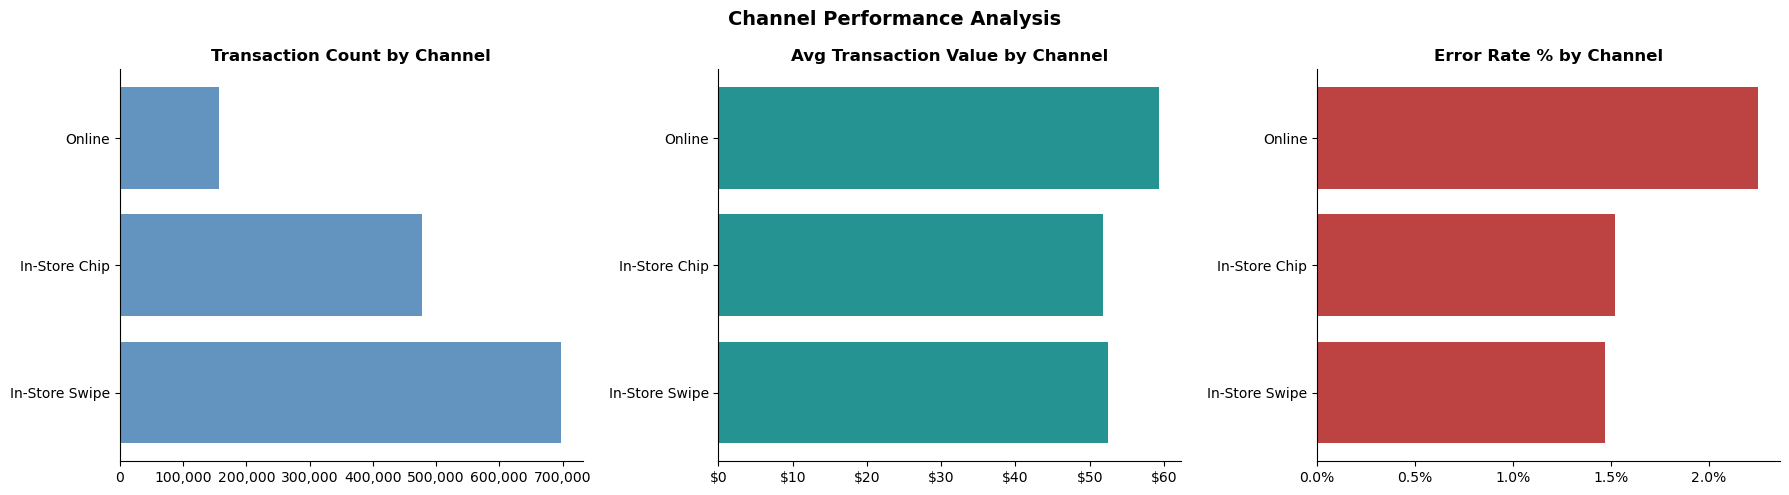

       channel  txn_count  txn_share_pct  total_volume  avg_txn_value  error_rate_pct
In-Store Swipe     697020          52.37 36,584,999.54          52.49            1.47
 In-Store Chip     477713          35.90 24,723,863.56          51.75            1.52
        Online     156096          11.73  9,267,089.18          59.37            2.25


In [22]:
channel_kpi = duckdb.query("""
    SELECT
        channel,
        COUNT(*)                                                           AS txn_count,
        ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(), 2)                     AS txn_share_pct,
        ROUND(SUM(amount_abs), 2)                                          AS total_volume,
        ROUND(AVG(amount_abs), 2)                                          AS avg_txn_value,
        ROUND(AVG(CASE WHEN has_error = 'True' THEN 1.0 ELSE 0 END)*100, 2) AS error_rate_pct
    FROM master
    GROUP BY channel
    ORDER BY txn_count DESC
""").df()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].barh(channel_kpi['channel'], channel_kpi['txn_count'], color='steelblue', alpha=0.85)
axes[0].set_title('Transaction Count by Channel', fontweight='bold')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))

axes[1].barh(channel_kpi['channel'], channel_kpi['avg_txn_value'], color='teal', alpha=0.85)
axes[1].set_title('Avg Transaction Value by Channel', fontweight='bold')
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

axes[2].barh(channel_kpi['channel'], channel_kpi['error_rate_pct'], color='firebrick', alpha=0.85)
axes[2].set_title('Error Rate % by Channel', fontweight='bold')
axes[2].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.1f}%'))

plt.suptitle('Channel Performance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DASHBOARD_DIR,'channel_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print(channel_kpi.to_string(index=False))

## KPI 4: Error Analysis

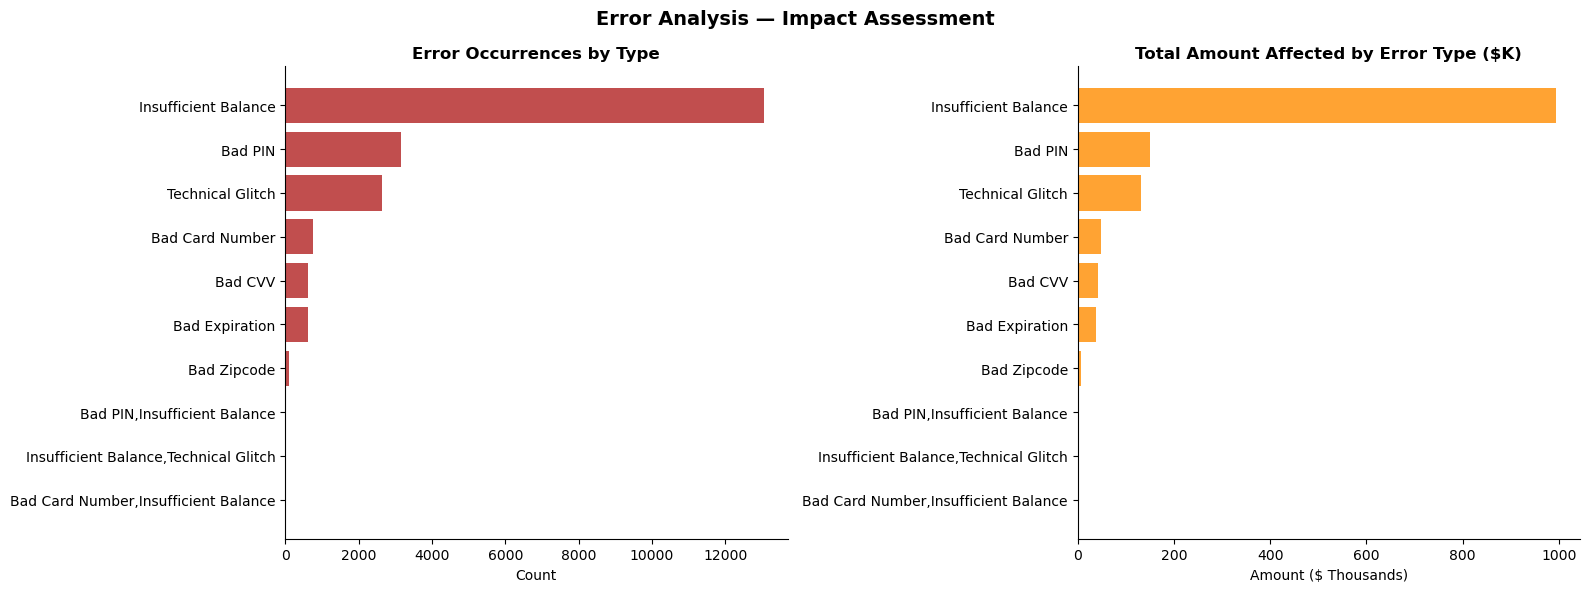

                           error_type  occurrences  share_pct  total_amount_affected  avg_amount_affected
                             No Error      1309810      98.42          69,161,425.92                52.80
                 Insufficient Balance        13039       0.98             994,213.19                76.25
                              Bad PIN         3147       0.24             150,252.51                47.74
                     Technical Glitch         2639       0.20             131,471.45                49.82
                      Bad Card Number          763       0.06              47,343.17                62.05
                              Bad CVV          632       0.05              41,865.83                66.24
                       Bad Expiration          611       0.05              37,448.97                61.29
                          Bad Zipcode          105       0.01               5,982.04                56.97
         Bad PIN,Insufficient Balance         

In [23]:
error_kpi = duckdb.query("""
    SELECT
        error_type,
        COUNT(*)                                                           AS occurrences,
        ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(), 2)                     AS share_pct,
        ROUND(SUM(amount_abs), 2)                                          AS total_amount_affected,
        ROUND(AVG(amount_abs), 2)                                          AS avg_amount_affected
    FROM master
    GROUP BY error_type
    ORDER BY occurrences DESC
""").df()

top_errors = error_kpi[error_kpi['error_type'] != 'No Error'].head(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.barh(top_errors['error_type'], top_errors['occurrences'], color='firebrick', alpha=0.8)
ax1.set_title('Error Occurrences by Type', fontweight='bold')
ax1.set_xlabel('Count')
ax1.invert_yaxis()

ax2.barh(top_errors['error_type'], top_errors['total_amount_affected']/1000, color='darkorange', alpha=0.8)
ax2.set_title('Total Amount Affected by Error Type ($K)', fontweight='bold')
ax2.set_xlabel('Amount ($ Thousands)')
ax2.invert_yaxis()

plt.suptitle('Error Analysis — Impact Assessment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DASHBOARD_DIR,'error_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print(error_kpi.to_string(index=False))

## KPI 5: Top Merchant Categories

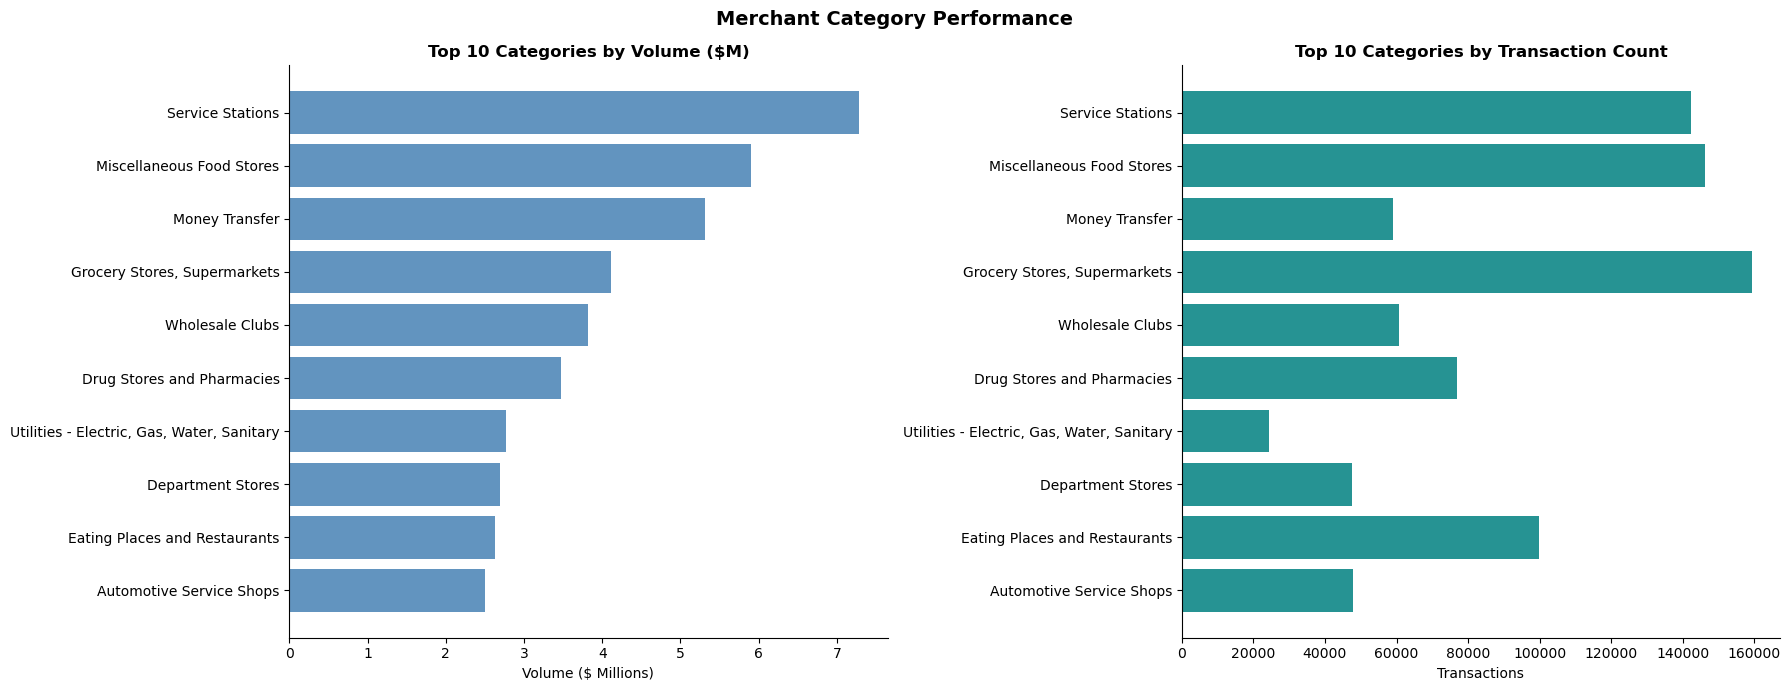

                         merchant_category  txn_count  total_volume  avg_txn_value  error_rate_pct
                          Service Stations     142172  7,282,118.94          51.22            1.72
                 Miscellaneous Food Stores     146068  5,907,446.94          40.44            1.46
                            Money Transfer      59029  5,317,021.28          90.07            3.17
              Grocery Stores, Supermarkets     159206  4,105,609.39          25.79            1.10
                           Wholesale Clubs      60717  3,813,640.66          62.81            1.99
                Drug Stores and Pharmacies      76859  3,478,834.30          45.26            1.64
Utilities - Electric, Gas, Water, Sanitary      24444  2,774,142.17         113.49            2.54
                         Department Stores      47686  2,689,326.69          56.40            2.01
             Eating Places and Restaurants      99869  2,629,655.43          26.33            1.02
          

In [24]:
merchant_kpi = duckdb.query("""
    SELECT
        merchant_category,
        COUNT(*)                                                           AS txn_count,
        ROUND(SUM(amount_abs), 2)                                          AS total_volume,
        ROUND(AVG(amount_abs), 2)                                          AS avg_txn_value,
        ROUND(AVG(CASE WHEN has_error = 'True' THEN 1.0 ELSE 0 END)*100, 2) AS error_rate_pct
    FROM master
    GROUP BY merchant_category
    ORDER BY total_volume DESC
    LIMIT 15
""").df()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

ax1.barh(merchant_kpi['merchant_category'][:10],
         merchant_kpi['total_volume'][:10]/1e6, color='steelblue', alpha=0.85)
ax1.set_title('Top 10 Categories by Volume ($M)', fontweight='bold')
ax1.set_xlabel('Volume ($ Millions)')
ax1.invert_yaxis()

ax2.barh(merchant_kpi['merchant_category'][:10],
         merchant_kpi['txn_count'][:10], color='teal', alpha=0.85)
ax2.set_title('Top 10 Categories by Transaction Count', fontweight='bold')
ax2.set_xlabel('Transactions')
ax2.invert_yaxis()

plt.suptitle('Merchant Category Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DASHBOARD_DIR,'merchant_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print(merchant_kpi.to_string(index=False))

## KPI 6: Customer Segment Analysis

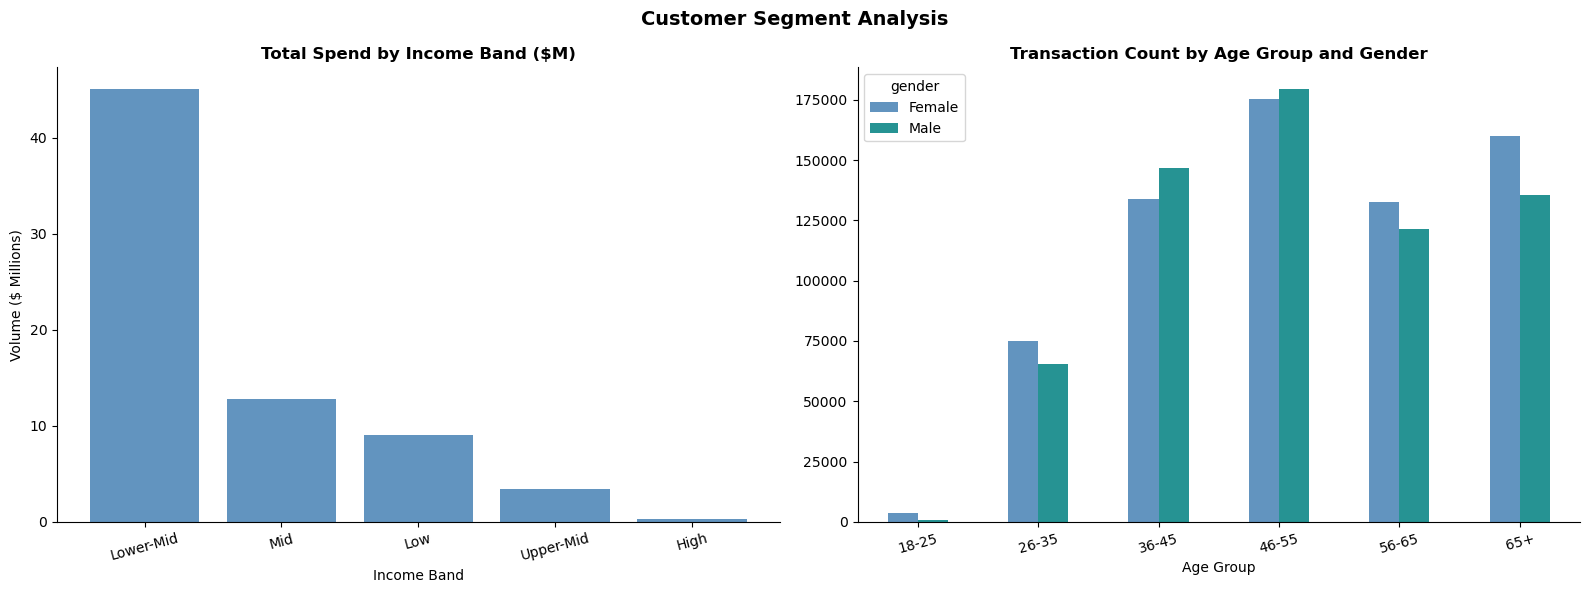

Income Band Summary:
income_band  unique_customers  txn_count   total_spend  avg_txn_value
  Lower-Mid               790     865821 45,089,557.98          52.08
        Mid               166     200004 12,807,384.83          64.04
        Low               230     220143  9,005,378.38          40.91
  Upper-Mid                31      42769  3,425,791.09          80.10
       High                 2       2092    247,840.00         118.47


In [25]:
age_kpi = duckdb.query("""
    SELECT
        age_group,
        gender,
        COUNT(*)                    AS txn_count,
        ROUND(SUM(amount_abs), 2)   AS total_volume,
        ROUND(AVG(amount_abs), 2)   AS avg_txn_value
    FROM master
    WHERE age_group IS NOT NULL
    AND gender IS NOT NULL
    GROUP BY age_group, gender
    ORDER BY age_group, gender
""").df()

income_kpi = duckdb.query("""
    SELECT
        income_band,
        COUNT(DISTINCT user_id)     AS unique_customers,
        COUNT(*)                    AS txn_count,
        ROUND(SUM(amount_abs), 2)   AS total_spend,
        ROUND(AVG(amount_abs), 2)   AS avg_txn_value
    FROM master
    WHERE income_band IS NOT NULL
    GROUP BY income_band
    ORDER BY total_spend DESC
""").df()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(income_kpi['income_band'], income_kpi['total_spend']/1e6,
            color='steelblue', alpha=0.85)
axes[0].set_title('Total Spend by Income Band ($M)', fontweight='bold')
axes[0].set_xlabel('Income Band')
axes[0].set_ylabel('Volume ($ Millions)')
axes[0].tick_params(axis='x', rotation=15)

age_pivot = age_kpi.pivot(index='age_group', columns='gender', values='txn_count').fillna(0)
age_pivot.plot(kind='bar', ax=axes[1], color=['steelblue', 'teal'], alpha=0.85)
axes[1].set_title('Transaction Count by Age Group and Gender', fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Customer Segment Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DASHBOARD_DIR,'customer_segments.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Income Band Summary:')
print(income_kpi.to_string(index=False))

## KPI 7: Card Performance Analysis

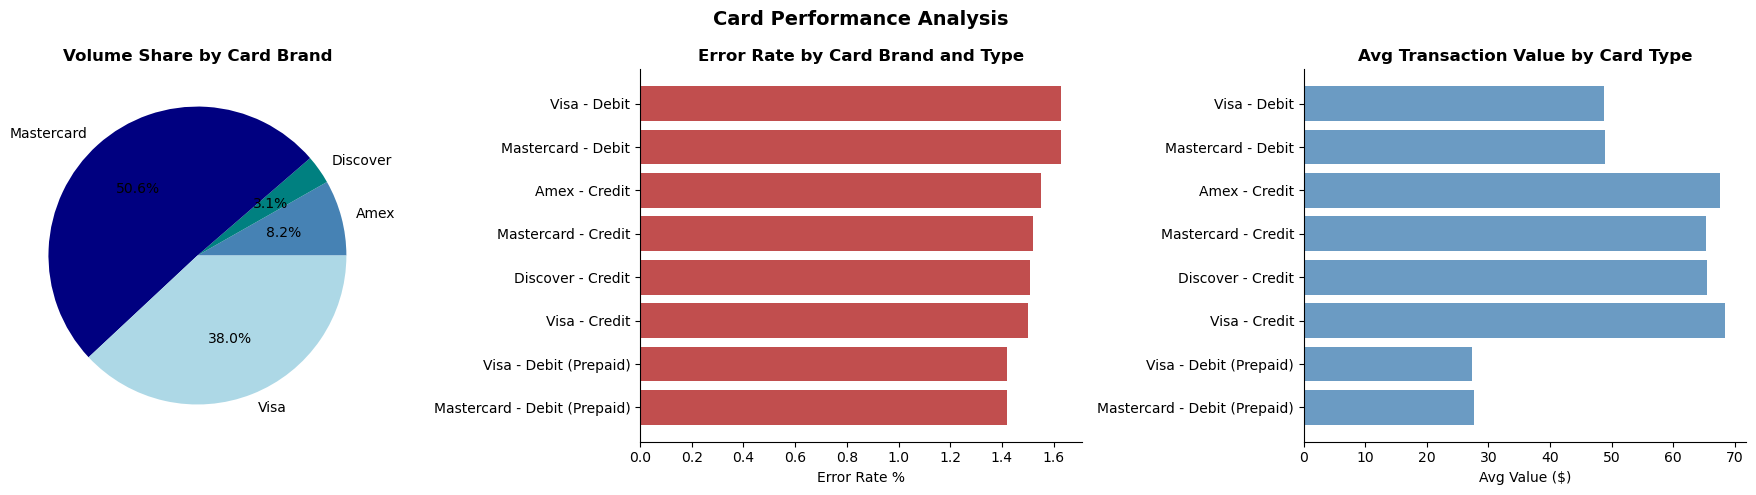

card_brand       card_type  txn_count  total_volume  avg_txn_value  error_rate_pct  high_risk_transactions
Mastercard           Debit     526594 25,781,158.91          48.96            1.63                    0.00
      Visa           Debit     301242 14,675,759.72          48.72            1.63                    0.00
      Visa          Credit     166314 11,386,770.17          68.47            1.50                    0.00
Mastercard          Credit     125278  8,193,098.34          65.40            1.52                    0.00
      Amex          Credit      85721  5,801,248.10          67.68            1.55                    0.00
  Discover          Credit      33662  2,205,365.40          65.51            1.51                    0.00
Mastercard Debit (Prepaid)      63354  1,751,406.56          27.64            1.42                    0.00
      Visa Debit (Prepaid)      28664    781,145.08          27.25            1.42                    0.00


In [26]:
card_kpi = duckdb.query("""
    SELECT
        card_brand,
        card_type,
        COUNT(*)                                                           AS txn_count,
        ROUND(SUM(amount_abs), 2)                                          AS total_volume,
        ROUND(AVG(amount_abs), 2)                                          AS avg_txn_value,
        ROUND(AVG(CASE WHEN has_error = 'True' THEN 1.0 ELSE 0 END)*100, 2) AS error_rate_pct,
        SUM(CASE WHEN is_high_risk = 'True' THEN 1 ELSE 0 END)            AS high_risk_transactions
    FROM master
    WHERE card_brand IS NOT NULL
    GROUP BY card_brand, card_type
    ORDER BY total_volume DESC
""").df()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

brand_vol = card_kpi.groupby('card_brand')['total_volume'].sum()
axes[0].pie(brand_vol, labels=brand_vol.index, autopct='%1.1f%%',
            colors=['steelblue', 'teal', 'navy', 'lightblue'])
axes[0].set_title('Volume Share by Card Brand', fontweight='bold')

card_sorted = card_kpi.sort_values('error_rate_pct', ascending=True)
axes[1].barh(card_sorted['card_brand'] + ' - ' + card_sorted['card_type'],
             card_sorted['error_rate_pct'], color='firebrick', alpha=0.8)
axes[1].set_title('Error Rate by Card Brand and Type', fontweight='bold')
axes[1].set_xlabel('Error Rate %')

axes[2].barh(card_sorted['card_brand'] + ' - ' + card_sorted['card_type'],
             card_sorted['avg_txn_value'], color='steelblue', alpha=0.8)
axes[2].set_title('Avg Transaction Value by Card Type', fontweight='bold')
axes[2].set_xlabel('Avg Value ($)')

plt.suptitle('Card Performance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DASHBOARD_DIR,'card_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print(card_kpi.to_string(index=False))

## KPI 8: Transaction Timing Patterns

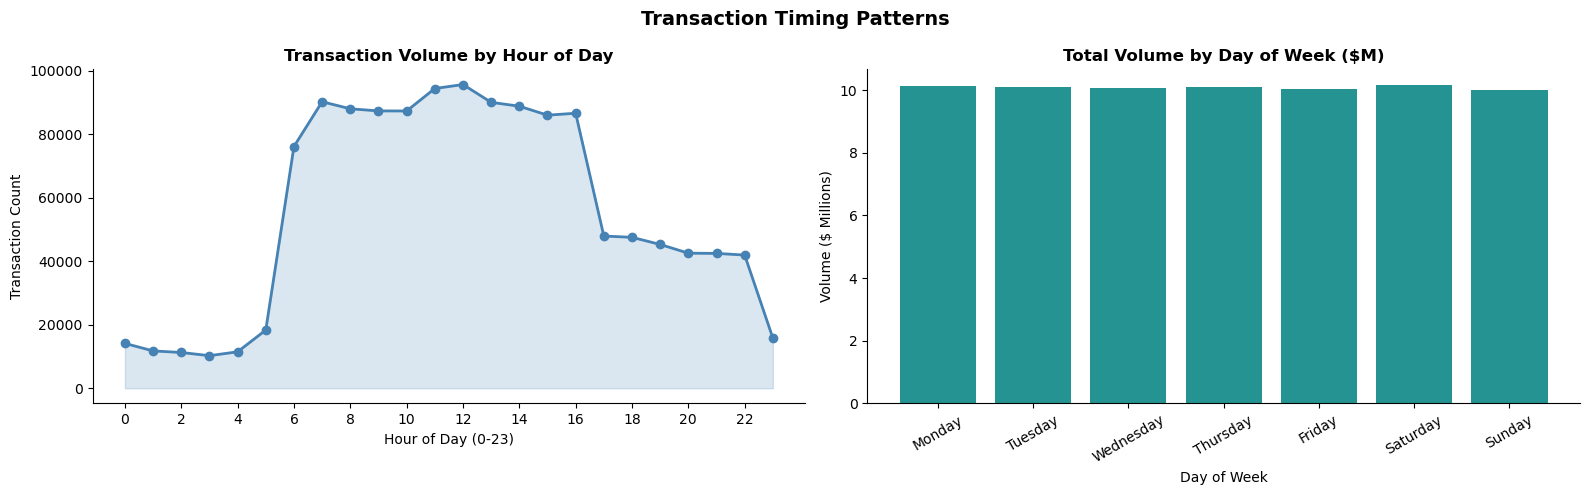

In [27]:
hourly = duckdb.query("""
    SELECT
        txn_hour,
        COUNT(*) AS txn_count,
        ROUND(AVG(amount_abs), 2) AS avg_value
    FROM master
    GROUP BY txn_hour
    ORDER BY txn_hour
""").df()

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = duckdb.query("""
    SELECT
        txn_dow,
        COUNT(*) AS txn_count,
        ROUND(SUM(amount_abs), 2) AS total_volume
    FROM master
    GROUP BY txn_dow
""").df()
dow['txn_dow'] = pd.Categorical(dow['txn_dow'], categories=dow_order, ordered=True)
dow = dow.sort_values('txn_dow')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.plot(hourly['txn_hour'], hourly['txn_count'],
         marker='o', color='steelblue', linewidth=2)
ax1.fill_between(hourly['txn_hour'], hourly['txn_count'], alpha=0.2, color='steelblue')
ax1.set_title('Transaction Volume by Hour of Day', fontweight='bold')
ax1.set_xlabel('Hour of Day (0-23)')
ax1.set_ylabel('Transaction Count')
ax1.set_xticks(range(0, 24, 2))

ax2.bar(dow['txn_dow'], dow['total_volume']/1e6, color='teal', alpha=0.85)
ax2.set_title('Total Volume by Day of Week ($M)', fontweight='bold')
ax2.set_xlabel('Day of Week')
ax2.set_ylabel('Volume ($ Millions)')
ax2.tick_params(axis='x', rotation=30)

plt.suptitle('Transaction Timing Patterns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DASHBOARD_DIR,'timing_patterns.png'), dpi=150, bbox_inches='tight')
plt.show()

## Key Business Insights

---

### Insight 1 — In-Store Swipe Dominates Volume but Online Carries the Highest Error Rate

In-Store Swipe accounts for the largest share of transactions by count — nearly 700,000 
transactions. However Online transactions show a materially higher error rate at 
approximately 2.2% compared to In-Store Chip at 1.5% and In-Store Swipe at 1.4%. 
Despite this, Online transactions carry the highest average ticket value at approximately 
$58 compared to $52-53 for in-store channels.

**Recommendation:** Online channel requires priority attention — it has the worst error 
rate and the highest value per transaction. Every failed online transaction costs more 
in lost revenue than a failed in-store transaction. A dedicated reliability review of 
the online payment gateway should be initiated immediately.

---

### Insight 2 — Insufficient Balance Drives Over 70% of All Transaction Errors

Insufficient Balance is overwhelmingly the top error type — accounting for approximately 
13,000 occurrences and over $1 million in affected transaction value. Bad PIN is a 
distant second at around 3,000 occurrences and Technical Glitch third at approximately 
2,800. The remaining error types — Bad Card Number, Bad CVV, Bad Expiration — are 
relatively minor in comparison.

**Recommendation:** Insufficient Balance errors are a customer behaviour issue, not a 
technical one. The business should consider implementing real-time balance alerts or 
pre-transaction balance checks to reduce these failures. Technical Glitch errors at 
2,800 occurrences represent the highest priority technical fix — these are fully within 
the business control to resolve.

---

### Insight 3 — Service Stations and Food Categories Dominate Both Volume and Frequency

Service Stations lead in both total volume at approximately $7.3M and transaction count 
at approximately 150,000. Miscellaneous Food Stores follows closely in both metrics. 
Grocery Stores and Supermarkets is the single highest category by transaction count 
at approximately 160,000 — surpassing even Service Stations — but ranks fourth by 
volume, indicating smaller average ticket sizes.

Money Transfer ranks third by volume at approximately $5.3M despite having far fewer 
transactions — indicating very high average transaction values in this category.

**Recommendation:** Money Transfer is a high value, lower frequency category that 
warrants dedicated fraud monitoring given the large amounts involved. Service Stations 
and Grocery categories being the highest frequency categories means any error rate 
improvement here has the largest volume impact on overall platform performance.

---

### Insight 4 — Lower-Mid Income Segment Drives Majority of Spend at $45M

The Lower-Mid income band dominates total spend by a significant margin at approximately 
$45M — more than three times the Mid band at $13M and five times the Low band at $9M. 
Upper-Mid and High income bands contribute negligibly at $3.5M and under $1M respectively.

The age analysis shows the 46-55 age group is the most active by transaction count for 
both Male and Female customers — followed closely by 65+ and 36-45. The 18-25 segment 
is by far the least active with minimal transactions.

**Recommendation:** The Lower-Mid income, 46-55 age group is clearly the core customer 
segment driving this platform. Retention, loyalty, and product decisions should be 
anchored around this profile. The 18-25 segment represents a significant untapped 
growth opportunity — targeted onboarding products for younger customers could materially 
expand the customer base over time.

---

### Insight 5 — Mastercard Leads Volume at 53.8% but Credit Cards Carry Higher Average Values

Mastercard accounts for 53.8% of total transaction volume followed by Visa at 38%. 
Discover and Amex together account for the remaining 8.3%. Error rates are largely 
consistent across all card brands and types at 1.4% to 1.6% — suggesting the error 
problem is platform-wide rather than card-brand specific.

Credit card types — Amex Credit, Visa Credit, Mastercard Credit, Discover Credit — 
all show average transaction values of $65-70, significantly higher than Debit cards 
at $50-55 and Prepaid Debit at approximately $25-28.

**Recommendation:** Prepaid Debit cards carry the lowest average transaction value 
and likely the thinnest margins. Credit card transactions represent the highest value 
segment and should receive priority reliability investment. The uniform error rate 
across all card brands confirms the error issue sits in the platform infrastructure 
rather than any specific card network integration.

---

### Insight 6 — Transaction Volume Peaks Between 7am and 4pm with a Sharp Evening Decline

The hourly chart shows a sharp ramp-up beginning at 6am, reaching peak volume between 
10am and 12pm at approximately 90,000-95,000 transactions per hour. Volume remains 
elevated through the afternoon until 4pm when a sharp drop occurs. Late night hours 
from midnight to 5am maintain a baseline of approximately 10,000-15,000 transactions 
per hour.

Day of week shows no meaningful difference — volume is virtually identical across all 
seven days at approximately $10M per day.

**Recommendation:** Day of week based campaigns or weekend promotions are unlikely to 
show differential results given the flat weekly pattern. Hour of day however is highly 
meaningful — peak operational staffing, fraud monitoring thresholds, and promotional 
timing should all be calibrated to the 7am-4pm peak window. Any system maintenance 
should be scheduled between midnight and 5am when volume is at its lowest.

In [28]:
# Export all KPI tables
kpi_overview.to_csv(os.path.join(CLEANED_DATA_DIR, 'kpi_executive_summary.csv'), index=False)
yearly.to_csv(os.path.join(CLEANED_DATA_DIR, 'kpi_yearly_trend.csv'), index=False)
channel_kpi.to_csv(os.path.join(CLEANED_DATA_DIR, 'kpi_channel_analysis.csv'), index=False)
error_kpi.to_csv(os.path.join(CLEANED_DATA_DIR, 'kpi_error_analysis.csv'), index=False)
merchant_kpi.to_csv(os.path.join(CLEANED_DATA_DIR, 'kpi_merchant_categories.csv'), index=False)
card_kpi.to_csv(os.path.join(CLEANED_DATA_DIR, 'kpi_card_performance.csv'), index=False)

print('All KPI tables exported to data/cleaned/')
print(f'   kpi_executive_summary.csv')
print(f'   kpi_yearly_trend.csv')
print(f'   kpi_channel_analysis.csv')
print(f'   kpi_error_analysis.csv')
print(f'   kpi_merchant_categories.csv')
print(f'   kpi_card_performance.csv')

All KPI tables exported to data/cleaned/
   kpi_executive_summary.csv
   kpi_yearly_trend.csv
   kpi_channel_analysis.csv
   kpi_error_analysis.csv
   kpi_merchant_categories.csv
   kpi_card_performance.csv
